# 🏆 Who will win the 2026 World Cup? — a Bayesian goals model in PyMC

*Introduction to Probabilistic Programming Languages · UBA Exactas · demo*

Every team gets a latent **skill** (à la TrueSkill / Elo), and matches turn that skill into
**goals** through a **Poisson** likelihood. Because we model the *score-line* — not just
win/draw/loss — a 7–1 tells the model far more than a 1–0: we **use all the information in
the result**. The pipeline is the classic probabilistic-programming loop:

1. **Prior** — every team gets a skill, *calibrated* so that simulating the whole tournament
   reproduces the probability of winning the cup implied by the **bookmaker odds**.
2. **Likelihood** — skill differences set each team's **expected goals**; the **goals
   actually scored** in the matches played are the data.
3. **Posterior** — PyMC (NUTS) gives the posterior distribution of every team's skill.
4. **Prediction** — we Monte-Carlo **simulate the rest of the tournament** thousands of
   times to get each team's **championship probability**, both *a priori* and *a posteriori*.
5. **Visualization** — a split **violin plot** (`Set2`) compares the **prior vs posterior
   distribution of winning** for a handful of teams.

> **Data snapshot — Tuesday 16 June 2026.** Results for **11–15 June are final**
>
> *Sources: 2026 final draw & fixtures (ESPN), title odds (Yahoo Sports / BetMGM).*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az

rng = np.random.default_rng(20260615)
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
sns.set_palette("Set2")
SET2 = sns.color_palette("Set2")
PRIOR_C, POST_C = SET2[0], SET2[1]       # green = prior, orange = posterior
print("PyMC", pm.__version__)

PyMC 6.0.1


## 1 · The 48 teams and 12 groups

The final draw splits 48 teams into 12 groups of four (the European and inter-confederation
play-off winners — Türkiye, Bosnia, Czechia, Sweden, Iraq, DR Congo — are already resolved).

In [2]:
GROUPS = {
    "A": ["Mexico", "South Korea", "South Africa", "Czechia"],
    "B": ["Canada", "Switzerland", "Qatar", "Bosnia"],
    "C": ["Brazil", "Morocco", "Scotland", "Haiti"],
    "D": ["USA", "Australia", "Paraguay", "Turkey"],
    "E": ["Germany", "Ecuador", "Ivory Coast", "Curacao"],
    "F": ["Netherlands", "Japan", "Tunisia", "Sweden"],
    "G": ["Belgium", "Iran", "Egypt", "New Zealand"],
    "H": ["Spain", "Uruguay", "Saudi Arabia", "Cape Verde"],
    "I": ["France", "Senegal", "Norway", "Iraq"],
    "J": ["Argentina", "Austria", "Algeria", "Jordan"],
    "K": ["Portugal", "Colombia", "Uzbekistan", "DR Congo"],
    "L": ["England", "Croatia", "Panama", "Ghana"],
}
GROUP_LETTERS = list(GROUPS)
teams   = [t for g in GROUP_LETTERS for t in GROUPS[g]]   # 48 teams, in group order
idx     = {t: i for i, t in enumerate(teams)}             # team name -> 0..47
team2group = {t: g for g in GROUP_LETTERS for t in GROUPS[g]}
N_TEAMS = len(teams)

pd.DataFrame({g: GROUPS[g] for g in GROUP_LETTERS}, index=["seed 1", "2", "3", "4"])

,A,B,C,D,E,F,G,H,I,J,K,L
seed 1,Mexico,Canada,Brazil,USA,Germany,Netherlands,Belgium,Spain,France,Argentina,Portugal,England
2,South Korea,Switzerland,Morocco,Australia,Ecuador,Japan,Iran,Uruguay,Senegal,Austria,Colombia,Croatia
3,South Africa,Qatar,Scotland,Paraguay,Ivory Coast,Tunisia,Egypt,Saudi Arabia,Norway,Algeria,Uzbekistan,Panama
4,Czechia,Bosnia,Haiti,Turkey,Curacao,Sweden,New Zealand,Cape Verde,Iraq,Jordan,DR Congo,Ghana


## 2 · From betting odds to a target championship distribution

The published futures odds are a mix of American (`+450`) and fractional (`14-1`) formats.
Both convert to an **implied probability** via the fractional odds $f$ (for American $+A$,
$f = A/100$):

$$p_{\text{implied}} = \frac{1}{f + 1}.$$

These implied probabilities **sum to more than 1** — the bookmaker's *overround* (vig).
Dividing by the sum removes the margin and leaves a proper distribution $q$ that we treat
as the *true* prior probability that each team wins the cup.

In [3]:
ODDS_FRAC = {  # fractional "X-to-1" (American +A stored as A/100)
    "Spain": 4.5, "France": 4.75, "England": 7, "Portugal": 7, "Argentina": 9,
    "Brazil": 9, "Germany": 14, "Netherlands": 20, "Belgium": 33, "Norway": 33,
    "Colombia": 40, "Morocco": 40, "Japan": 50, "USA": 50, "Mexico": 66,
    "Senegal": 66, "Switzerland": 66, "Turkey": 66, "Uruguay": 66, "Croatia": 80,
    "Ecuador": 80, "Sweden": 100, "Austria": 150, "Canada": 150, "Ivory Coast": 200,
    "South Korea": 200, "Algeria": 250, "Bosnia": 250, "Egypt": 250, "Paraguay": 250,
    "Scotland": 250, "Czechia": 300, "Australia": 500, "Ghana": 500, "Iran": 500,
    "Tunisia": 500, "DR Congo": 750, "Cape Verde": 1000, "Iraq": 1000, "Jordan": 1000,
    "New Zealand": 1000, "Panama": 1000, "Qatar": 1000, "Saudi Arabia": 1000,
    "South Africa": 1000, "Uzbekistan": 1000, "Curacao": 2500, "Haiti": 2500,
}
implied  = np.array([1.0 / (ODDS_FRAC[t] + 1.0) for t in teams])
overround = implied.sum()
q_odds   = implied / overround           # de-vigged target distribution
print(f"Overround (sum of implied probabilities) = {overround:.3f}  "
      f"-> {(overround-1)*100:.0f}% bookmaker margin")

Overround (sum of implied probabilities) = 1.242  -> 24% bookmaker margin


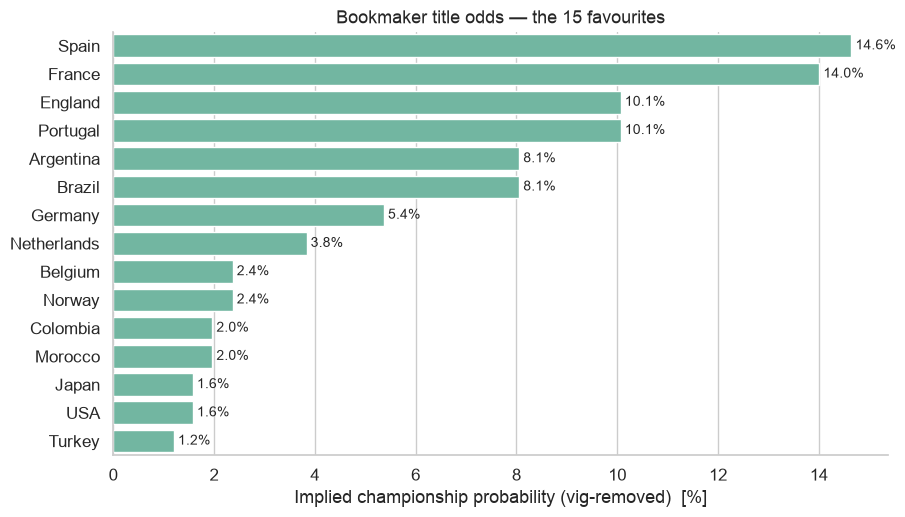

In [4]:
# Top of the market
top = np.argsort(-q_odds)[:15]
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(x=[q_odds[i]*100 for i in top], y=[teams[i] for i in top],
            color=PRIOR_C, ax=ax)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, fontsize=10)
ax.set(xlabel="Implied championship probability (vig-removed)  [%]", ylabel="",
       title="Bookmaker title odds — the 15 favourites")
sns.despine(); plt.show()

## 3 · The results we have seen


In [5]:
# (date, home, away, home_goals, away_goals)  — FINAL results so far
OBSERVED = [
    ("Jun 11", "Mexico", "South Africa", 2, 0),
    ("Jun 11", "South Korea", "Czechia", 2, 1),
    ("Jun 12", "Canada", "Bosnia", 1, 1),
    ("Jun 12", "USA", "Paraguay", 4, 1),
    ("Jun 13", "Haiti", "Scotland", 0, 1),
    ("Jun 13", "Brazil", "Morocco", 1, 1),
    ("Jun 13", "Qatar", "Switzerland", 1, 1),
    ("Jun 13", "Australia", "Turkey", 2, 0),
    ("Jun 14", "Germany", "Curacao", 7, 1),
    ("Jun 14", "Netherlands", "Japan", 2, 2),
    ("Jun 14", "Ivory Coast", "Ecuador", 1, 0),
    ("Jun 14", "Sweden", "Tunisia", 5, 1),
    ("Jun 15", "Belgium", "Egypt", 1, 1),
    ("Jun 15", "Iran", "New Zealand", 2, 2),
    ("Jun 15", "Spain", "Cape Verde", 0, 0),
    ("Jun 15", "Saudi Arabia", "Uruguay", 1, 1),
    ("Jun 16", "France", "Senegal", 3, 1),
    ("Jun 16", "Iraq", "Norway", 1, 4),
    ("Jun 16", "Argentina", "Algeria", 3, 0)
]
# remaining match-day-1 fixtures (16-17 June) — simulated, not yet observed
REMAINING = [
    ("Jun 16", "Austria", "Jordan"),
    ("Jun 17", "Portugal", "DR Congo"), ("Jun 17", "Uzbekistan", "Colombia"),
    ("Jun 17", "England", "Croatia"), ("Jun 17", "Ghana", "Panama"),
]

def _res(hg, ag): return "home win" if hg > ag else ("draw" if hg == ag else "away win")
played = pd.DataFrame(
    [(d, team2group[h], h, f"{hg}-{ag}", a, _res(hg, ag)) for d, h, a, hg, ag in OBSERVED],
    columns=["date", "grp", "home", "score", "away", "result"])
print(f"{len(OBSERVED)} matches played, {len(REMAINING)} match-day-1 games still to come")
played

19 matches played, 5 match-day-1 games still to come


,date,grp,home,score,away,result
0,Jun 11,A,Mexico,2-0,South Africa,home win
1,Jun 11,A,South Korea,2-1,Czechia,home win
2,Jun 12,B,Canada,1-1,Bosnia,draw
3,Jun 12,D,USA,4-1,Paraguay,home win
4,Jun 13,C,Haiti,0-1,Scotland,away win
5,Jun 13,C,Brazil,1-1,Morocco,draw
6,Jun 13,B,Qatar,1-1,Switzerland,draw
7,Jun 13,D,Australia,2-0,Turkey,home win
8,Jun 14,E,Germany,7-1,Curacao,home win
9,Jun 14,F,Netherlands,2-2,Japan,draw


## 4 · The model: skills that score goals

Give every team a latent **skill** $s_t$. A match between *home* $a$ and *away* $b$ is driven
by the skill gap; the stronger side has the higher **expected number of goals**, and the
actual goals are Poisson:

$$
s_t \sim \mathcal{N}(\mu_t,\ \sigma_s)
$$
$$
\lambda_a = \lambda_0\,\exp\!\big(\beta\,(s_a - s_b)\big), \qquad
\lambda_b = \lambda_0\,\exp\!\big(\beta\,(s_b - s_a)\big)
$$
$$
y_a \sim \operatorname{Poisson}(\lambda_a), \qquad
y_b \sim \operatorname{Poisson}(\lambda_b)
$$

- $\lambda_0$ — baseline goals a team scores against an equal opponent;
- $\beta$ — how sharply a skill edge converts into goals;
- $\sigma_s$ — prior spread of skill.

Modelling the **score** lets the model *use more information*:
a 7–1 score moves a team's skill much more than a narrow 1–0. Because we simulate
goals, group standings use the real FIFA tie-breakers — **points, then goal difference, then
goals for** — and knockout ties go to a penalty shoot-out (a coin flip).

In [6]:
SIGMA_S = 1.0     # prior standard deviation of each team's skill
LAMBDA0 = 1.3     # baseline goals per team vs an equal opponent (≈ real WC average)
BETA    = 0.30    # skill-gap -> log goal-rate sensitivity

# build, per group, the 6 round-robin matches as within-group positions (a,b)
# with match-day-1 pairings fixed to the real fixtures, and attach observed *goals*.
MD1 = {"A": ((0,2),(1,3)), "B": ((0,3),(2,1)), "C": ((3,2),(0,1)), "D": ((0,2),(1,3)),
       "E": ((0,3),(2,1)), "F": ((0,1),(3,2)), "G": ((0,2),(1,3)), "H": ((0,3),(2,1)),
       "I": ((0,1),(3,2)), "J": ((0,2),(1,3)), "K": ((0,3),(2,1)), "L": ((0,1),(3,2))}
obs_lookup = {frozenset((h, a)): (h, a, hg, ag) for _, h, a, hg, ag in OBSERVED}

group_matches = []   # 12 groups x 6 matches of (pos_x, pos_y, fixed_goals | None)
for g in GROUP_LETTERS:
    (a, b), (c, d) = MD1[g]
    pairs = [(a, b), (c, d), (a, c), (b, d), (a, d), (b, c)]   # full round robin
    rows = []
    for k, (px, py) in enumerate(pairs):
        fg = None
        if k < 2:                                             # a match-day-1 game
            rec = obs_lookup.get(frozenset((GROUPS[g][px], GROUPS[g][py])))
            if rec is not None:
                h, _, hg, ag = rec                            # orient goals to (px, py)
                fg = (hg, ag) if h == GROUPS[g][px] else (ag, hg)
        rows.append((px, py, fg))
    group_matches.append(rows)

# data arrays for PyMC: home/away team indices and goals scored
home_idx = np.array([idx[h] for _, h, a, hg, ag in OBSERVED])
away_idx = np.array([idx[a] for _, h, a, hg, ag in OBSERVED])
hg_obs   = np.array([hg for _, h, a, hg, ag in OBSERVED])
ag_obs   = np.array([ag for _, h, a, hg, ag in OBSERVED])
print("home goals:", hg_obs, "\naway goals:", ag_obs)

home goals: [2 2 1 4 0 1 1 2 7 2 1 5 1 2 0 1 3 1 3] 
away goals: [0 1 1 1 1 1 1 0 1 2 0 1 1 2 0 1 1 4 0]


### The vectorized tournament simulator

One function simulates `N` whole tournaments at once (groups → 8 best third-placed teams
→ a seeded 32-team knockout bracket) and returns the champion of each. Every match draws a
**Poisson score-line**; it is pure NumPy, so hundreds of thousands of tournaments run in a
few seconds. Passing `use_observed=False` re-simulates *every* match (used for the prior and
for calibration); `use_observed=True` **freezes the score-lines already played** and only
simulates the future.

In [7]:
# standard 32-team seeded bracket: seed 1 and seed 2 can only meet in the final
BRACKET_POS = np.array([1,32,16,17,8,25,9,24,4,29,13,20,5,28,12,21,
                        2,31,15,18,7,26,10,23,3,30,14,19,6,27,11,22]) - 1

def goals(diff, rng):
    # diff = s_a - s_b  ->  Poisson goals for both sides
    return (rng.poisson(LAMBDA0 * np.exp( BETA * diff)),
            rng.poisson(LAMBDA0 * np.exp(-BETA * diff)))

def simulate_tournament(skills, rng, use_observed=True):
    # skills: (N, 48) array of team skills -> champion team index per sim (N,)
    N  = skills.shape[0]
    ar = np.arange(N)
    g_win = np.empty((N, 12), np.int64); g_run = np.empty((N, 12), np.int64)
    t_team = np.empty((N, 12), np.int64); t_key = np.empty((N, 12))
    for gi in range(12):                                   # ---- group stage ----
        base = 4 * gi
        gs = skills[:, base:base + 4]
        pts = np.zeros((N, 4)); gf = np.zeros((N, 4)); ga = np.zeros((N, 4))
        for px, py, fg in group_matches[gi]:
            if use_observed and fg is not None:            # frozen real score-line
                yx = np.full(N, fg[0]); yy = np.full(N, fg[1])
            else:                                          # simulate the score-line
                yx, yy = goals(gs[:, px] - gs[:, py], rng)
            gf[:, px] += yx; ga[:, px] += yy; gf[:, py] += yy; ga[:, py] += yx
            pts[:, px] += 3 * (yx > yy) + (yx == yy)
            pts[:, py] += 3 * (yy > yx) + (yx == yy)
        # rank by points, then goal difference, then goals for (+ tiny jitter)
        key   = pts * 1e4 + (gf - ga) * 1e2 + gf + rng.random((N, 4)) * 1e-3
        order = np.argsort(-key, axis=1)
        g_win[:, gi] = base + order[:, 0]
        g_run[:, gi] = base + order[:, 1]
        third = order[:, 2]
        t_team[:, gi] = base + third
        t_key[:, gi]  = key[ar, third]
    # ---- 8 best third-placed teams ----
    best8 = np.take_along_axis(
        t_team, np.argsort(-(t_key + rng.random((N, 12)) * 1e-3), axis=1)[:, :8], axis=1)
    # ---- seed the 32 qualifiers (winners > runners-up > thirds, then by skill) ----
    qual  = np.concatenate([g_win, g_run, best8], axis=1)
    tiers = np.array([2]*12 + [1]*12 + [0]*8)
    seedscore = tiers * 100.0 + np.take_along_axis(skills, qual, axis=1) + rng.random((N, 32))*1e-6
    seeded = np.take_along_axis(qual, np.argsort(-seedscore, axis=1), axis=1)
    cur = seeded[:, BRACKET_POS]
    while cur.shape[1] > 1:                                 # ---- knockout rounds ----
        a, b = cur[:, 0::2], cur[:, 1::2]
        ya, yb = goals(np.take_along_axis(skills, a, axis=1)
                       - np.take_along_axis(skills, b, axis=1), rng)
        a_adv = np.where(ya == yb, rng.random(a.shape) < 0.5, ya > yb)  # tie -> shoot-out
        cur = np.where(a_adv, a, b)
    return cur[:, 0]

## 5 · Calibrating the prior to the odds

We want the prior skills $\mu_t$ such that *simulating the whole tournament from the prior*
reproduces the bookmaker probabilities $q_t$. Championship probability is a stiff function of skill, so we solve it with a short **fixed-point loop**: simulate,
compare the simulated title share to the target, and nudge each $\mu_t$ by the log-ratio.
A small learning rate plus averaging the last iterations keeps it stable.

In [8]:
def calibrate(q, n_cal=35000, iters=45, avg_tail=20, lr=0.5, seed=1):
    cr   = np.random.default_rng(seed)
    logq = np.log(q)
    mu   = logq - logq.mean()
    tail = []
    for it in range(iters):
        sk    = mu + SIGMA_S * cr.standard_normal((n_cal, N_TEAMS))
        champ = simulate_tournament(sk, cr, use_observed=False)
        p     = (np.bincount(champ, minlength=N_TEAMS) + 0.5) / (n_cal + 0.5 * N_TEAMS)
        mu    = mu + lr * (logq - np.log(p))
        mu   -= mu.mean()
        if it >= iters - avg_tail:
            tail.append(mu.copy())
    return np.mean(tail, axis=0)

mu_cal = calibrate(q_odds)

# verify: simulate 120k tournaments from the calibrated prior
sk_chk  = mu_cal + SIGMA_S * rng.standard_normal((120_000, N_TEAMS))
p_prior = np.bincount(simulate_tournament(sk_chk, rng, use_observed=False),
                      minlength=N_TEAMS) / 120_000
print(f"calibration quality (log-prob corr) = "
      f"{np.corrcoef(np.log(q_odds), np.log(p_prior + 1e-9))[0,1]:.4f}")

calibration quality (log-prob corr) = 0.9991


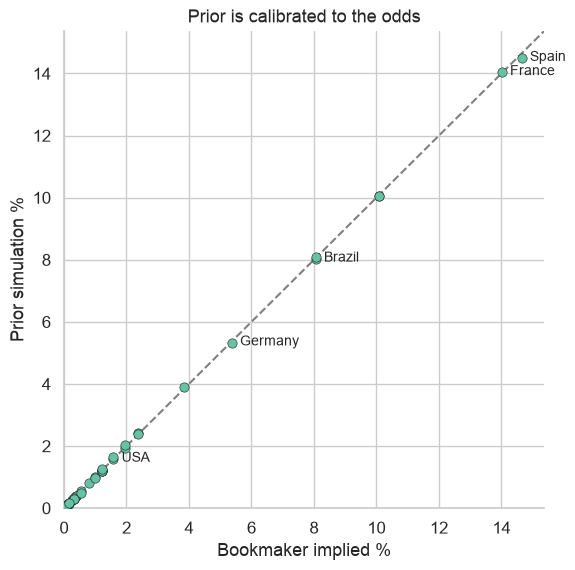

In [9]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))
ax.scatter(q_odds*100, p_prior*100, s=45, color=PRIOR_C, edgecolor="k", lw=0.4, zorder=3)
lim = max(q_odds.max(), p_prior.max())*100*1.05
ax.plot([0, lim], [0, lim], "--", color="grey", zorder=1)
for t in ["Spain", "France", "Brazil", "Germany", "USA"]:
    ax.annotate(t, (q_odds[idx[t]]*100, p_prior[idx[t]]*100),
                xytext=(6, -2), textcoords="offset points", fontsize=10)
ax.set(xlabel="Bookmaker implied %", ylabel="Prior simulation %",
       title="Prior is calibrated to the odds", xlim=(0, lim), ylim=(0, lim))
sns.despine(); plt.show()

## 6 · Bayesian updating with PyMC

The likelihood is now **Poisson on the goals**: each played match contributes two counts,
the home goals and the away goals, with means $\lambda_a,\lambda_b$ set by the skill gap.
NUTS returns the posterior over all 48 skills.

In [10]:
with pm.Model() as model:
    skill = pm.Normal("skill", mu=mu_cal, sigma=SIGMA_S, shape=N_TEAMS)
    diff  = skill[home_idx] - skill[away_idx]
    lam_a = LAMBDA0 * pm.math.exp( BETA * diff)
    lam_b = LAMBDA0 * pm.math.exp(-BETA * diff)
    pm.Poisson("home_goals", mu=lam_a, observed=hg_obs)
    pm.Poisson("away_goals", mu=lam_b, observed=ag_obs)
    idata = pm.sample(4000, tune=1000, chains=4, target_accept=0.9,
                      random_seed=7, progressbar=False)

post = idata.posterior["skill"].values.reshape(-1, N_TEAMS)   # (draws, 48)
print("max R-hat =", float(az.rhat(idata)["skill"].max()),
      "| divergences =", int(idata.sample_stats["diverging"].values.sum()))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [skill]
Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 1 seconds.


max R-hat = 1.0010592384418349 | divergences = 0


### Why the skills move: expected vs actual score-lines

The update is driven by the gap between what the *prior* expected and what *happened*. Under
the calibrated prior means, each played match has an expected score-line $\lambda_a$–$\lambda_b$;
the surprise is how far the real goal difference landed from it. Germany were *expected* to
beat Curaçao by about 2½ goals. The actual **7–1** is a huge positive surprise, so Germany's
skill jumps. Brazil's **1–1** with Morocco is a negative surprise, so Brazil slips.

In [11]:
rows = []
for d, h, a, hg, ag in OBSERVED:
    delta = mu_cal[idx[h]] - mu_cal[idx[a]]
    ea, eb = LAMBDA0*np.exp(BETA*delta), LAMBDA0*np.exp(-BETA*delta)
    rows.append((f"{h} v {a}", f"{ea:.1f}-{eb:.1f}", f"{hg}-{ag}",
                 (hg - ag) - (ea - eb)))
exp_act = (pd.DataFrame(rows, columns=["match", "expected", "actual", "surprise (GD)"])
             .sort_values("surprise (GD)", key=abs, ascending=False)
             .round(2).reset_index(drop=True))
exp_act

,match,expected,actual,surprise (GD)
0,Germany v Curacao,3.0-0.6,7-1,3.62
1,Sweden v Tunisia,1.7-1.0,5-1,3.35
2,Spain v Cape Verde,3.4-0.5,0-0,-2.87
3,Australia v Turkey,1.0-1.8,2-0,2.82
4,USA v Paraguay,1.7-1.0,4-1,2.31
5,Iraq v Norway,0.8-2.2,1-4,-1.56
6,Ivory Coast v Ecuador,1.1-1.5,1-0,1.39
7,Argentina v Algeria,2.4-0.7,3-0,1.34
8,Saudi Arabia v Uruguay,0.9-1.9,1-1,1.08
9,Qatar v Switzerland,0.9-1.9,1-1,1.05


### How did few match-days move the skills?

Only the teams that played can move. The dumbbell shows each team's prior mean skill (grey)
and posterior mean skill (coloured) — **green = rose, red = fell**. With the goals model the
*margin* matters: **Germany** (7–1) and **Sweden** (5–1) leap; **Australia** climbs after
beating Türkiye; **Brazil**, **Switzerland** and **Netherlands** slip after dropping points;
**Curaçao** sinks after conceding seven.

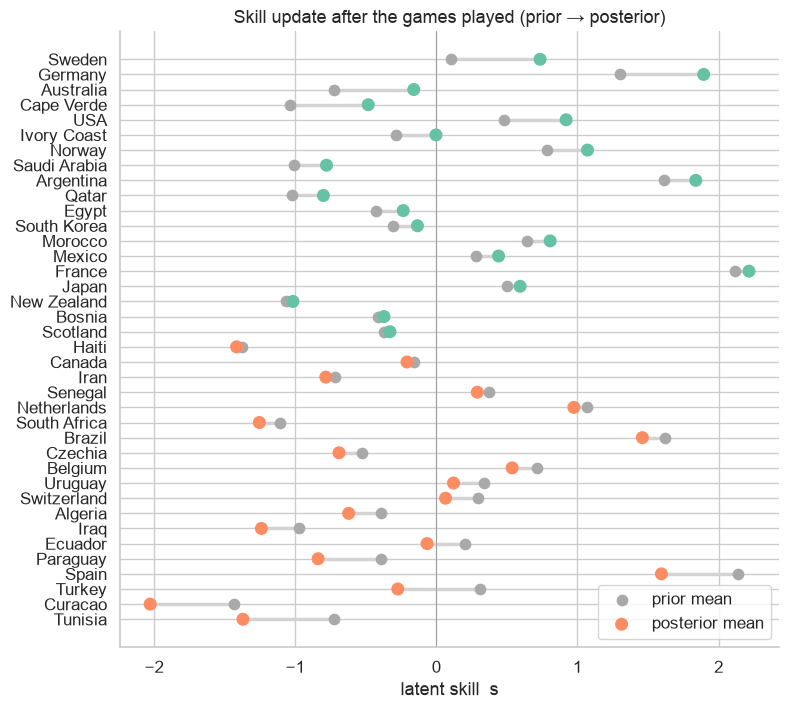

In [12]:
played_teams = [t for t in teams if idx[t] in set(home_idx) | set(away_idx)]
dd = (pd.DataFrame([(t, mu_cal[idx[t]], post[:, idx[t]].mean()) for t in played_teams],
                   columns=["team", "prior", "post"])
        .assign(delta=lambda d: d.post - d.prior).sort_values("delta"))

fig, ax = plt.subplots(figsize=(8.5, 8))
y = np.arange(len(dd))
ax.hlines(y, dd.prior, dd.post, color="lightgray", lw=2.5, zorder=1)
ax.scatter(dd.prior, y, color="darkgray", s=55, zorder=2, label="prior mean")
ax.scatter(dd.post, y, s=70, zorder=3, label="posterior mean",
           color=[SET2[0] if v > 0 else SET2[1] for v in dd.delta])
ax.set_yticks(y); ax.set_yticklabels(dd.team)
ax.axvline(0, color="k", lw=0.6, alpha=0.3)
ax.set(xlabel="latent skill  s", ylabel="",
       title="Skill update after the games played (prior → posterior)")
ax.legend(loc="lower right"); sns.despine(); plt.show()

## 7 · Simulating the rest of the tournament

For the **distribution of winning** we use a *nested* simulation. For each of `S` skill
draws (from the prior, or from the posterior) we play out `K` whole tournaments and record
how often each team is champion — giving that draw's championship probability. The spread
across the `S` draws is exactly our **uncertainty about each team's title chance**.

- **Prior** — draw skills from the prior and simulate *everything* (the world before a ball
  was kicked).
- **Posterior** — draw skills from the posterior and **freeze the played score-lines**,
  simulating only what is left (the world as of today).

In [13]:
def champ_distribution(skill_draws, rng, use_observed, K=400):
    S = skill_draws.shape[0]
    champ = simulate_tournament(np.repeat(skill_draws, K, axis=0),
                                rng, use_observed).reshape(S, K)
    return np.stack([(champ == t).mean(axis=1) for t in range(N_TEAMS)], axis=1)  # (S,48)

S, K = 1500, 400
prior_draws = mu_cal + SIGMA_S * rng.standard_normal((S, N_TEAMS))
post_draws  = post[rng.integers(0, post.shape[0], S)]

P_prior = champ_distribution(prior_draws, rng, use_observed=False, K=K)
P_post  = champ_distribution(post_draws,  rng, use_observed=True,  K=K)

summary = (pd.DataFrame({"team": teams,
                         "prior %": P_prior.mean(0)*100,
                         "posterior %": P_post.mean(0)*100})
             .assign(**{"Δ": lambda d: d["posterior %"] - d["prior %"]})
             .sort_values("posterior %", ascending=False)
             .head(12).round(2).reset_index(drop=True))
summary

,team,prior %,posterior %,Δ
0,France,14.15,14.99,0.84
1,England,9.69,10.74,1.05
2,Germany,5.50,10.61,5.10
3,Argentina,8.46,10.42,1.96
4,Portugal,9.67,10.26,0.60
5,Spain,14.21,7.60,-6.61
6,Brazil,8.29,6.06,-2.23
7,Norway,2.41,3.28,0.87
8,USA,1.45,3.18,1.73
9,Netherlands,4.15,3.18,-0.97


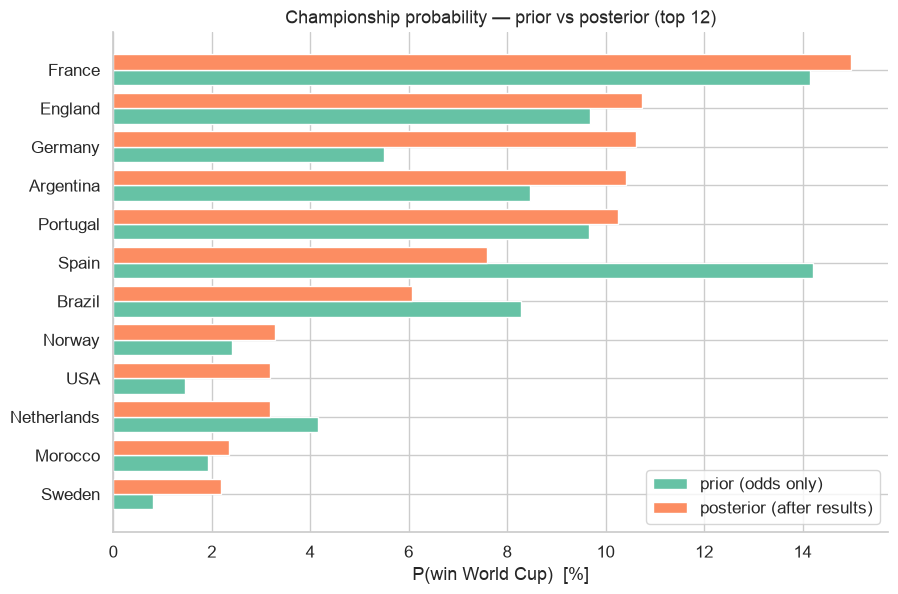

In [14]:
fig, ax = plt.subplots(figsize=(10, 6.5))
tt = summary["team"][::-1]; yv = np.arange(len(tt))
ax.barh(yv - 0.2, summary["prior %"][::-1], height=0.4, color=PRIOR_C, label="prior (odds only)")
ax.barh(yv + 0.2, summary["posterior %"][::-1], height=0.4, color=POST_C, label="posterior (after results)")
ax.set_yticks(yv); ax.set_yticklabels(tt)
ax.set(xlabel="P(win World Cup)  [%]", ylabel="",
       title="Championship probability — prior vs posterior (top 12)")
ax.legend(loc="lower right"); sns.despine(); plt.show()

## 8 · Prior vs posterior

The headline picture. For a handful of teams we draw the **full distribution** of the
championship probability, **prior on the left, posterior on the right** of each violin
(dashed lines = quartiles). Because the model reads the score-line, one match-day already
reshapes the title race.

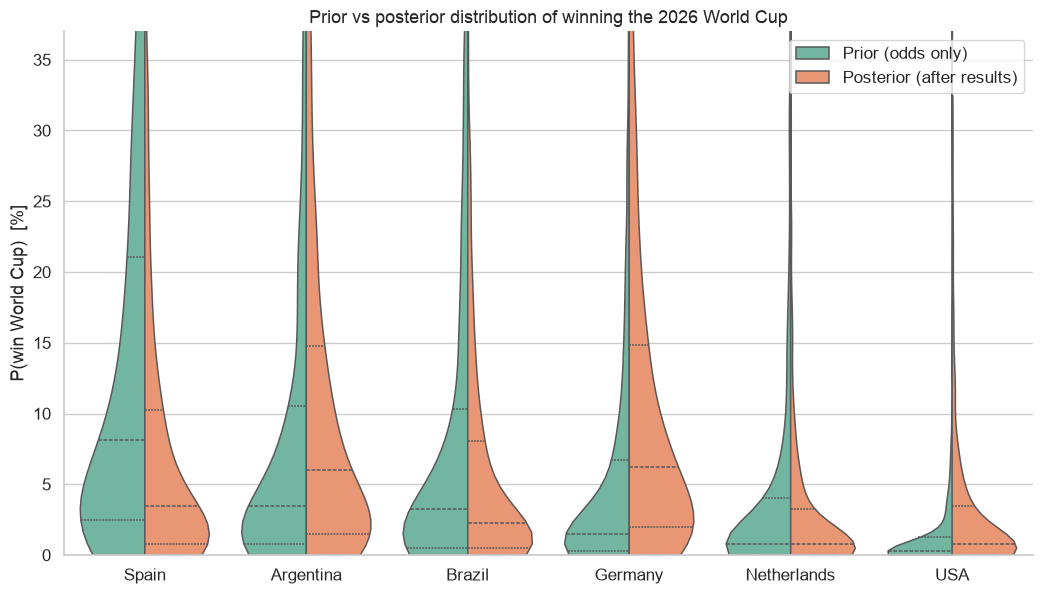

In [15]:
FEATURED = ["Spain", "Argentina", "Brazil", "Germany", "Netherlands", "USA"]
order = sorted(FEATURED, key=lambda t: -P_prior[:, idx[t]].mean())

rows = []
for t in order:
    i = idx[t]
    rows += [(t, "Prior (odds only)", v*100) for v in P_prior[:, i]]
    rows += [(t, "Posterior (after results)", v*100) for v in P_post[:, i]]
vdf = pd.DataFrame(rows, columns=["team", "phase", "pwin"])

fig, ax = plt.subplots(figsize=(12.5, 6.8))
sns.violinplot(data=vdf, x="team", y="pwin", hue="phase",
               hue_order=["Prior (odds only)", "Posterior (after results)"],
               split=True, cut=0, inner="quartile", density_norm="width",
               palette="Set2", order=order, linewidth=1.1, ax=ax)
ax.set_ylim(0, np.percentile(vdf["pwin"], 97))
ax.set(xlabel="", ylabel="P(win World Cup)  [%]",
       title="Prior vs posterior distribution of winning the 2026 World Cup")
ax.legend(title="", loc="upper right", frameon=True)
sns.despine(); plt.show()

## 9 · Takeaways

- **Calibrated prior.** Encoding the bookmaker odds as latent skills makes the model's *a
  priori* title race indistinguishable from the betting market — a principled, transparent
  starting point.
- **Goals carry information.** Modelling the score-line with a Poisson likelihood means the
  *margin* updates our beliefs: a 7–1 is strong evidence, a narrow win is weak evidence, and
  a favourite held to a draw actually loses ground. Surprising score-lines move the title
  race; expected ones barely do.
- **Honest uncertainty.** The violins show the race is *wide* — even the favourite's
  posterior runs from a couple of percent to the high tens.


**Modelling choices & simplifications.** Skill is a single rating (neutral venues, no
explicit home edge); home- and away-goal rates share one $\lambda_0$ and one $\beta$; group tie-breakers use points → goal difference →
goals for; the knockout bracket is a standard strength-seeded 32-team draw rather than FIFA's
exact third-place allocation table.